In [ ]:
from scipy.io import loadmat
import numpy as np
# 加载 .mat 文件
GNSS_data = loadmat('workbench/workbench/Earthquake_predictor/reference_project/RSIT/GNSS_South_central_Alaska_20180101_20181231.mat')['GNSS_South_central_Alaska_20180101_20181231']
print(GNSS_data.shape)
earthquake_data = loadmat('/home/linhang/workbench/workbench/Earthquake_predictor/reference_project/RSIT/South_central_Alaska_earthquake_event.mat')['South_central_Alaska_earthquake_event']
print(earthquake_data.shape)

In [ ]:
def myLeakyRelu(x, leak, flag):
    """
    Apply LeakyReLU activation function.

    Args:
        x (ndarray): Input data.
        leak (float): Slope for negative values.
        flag (int): 1 for standard LeakyReLU, 2 for inverse LeakyReLU.

    Returns:
        ndarray: Activated output.
    """
    myleak = leak if flag == 1 else 1 / leak
    output = np.where(x >= 0, x, myleak * x)
    return output

In [ ]:

def NN_transform(traindata, weights):
    """
    Transform data using a neural network structure.

    Args:
        traindata (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata.shape
    output = np.zeros((weights[-1].shape[1], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata[:, i]  # Input for the current timestep
        for weight in weights:
            curr_layer_nodes_value = np.dot(pre_layer_nodes_value, weight)
            # Apply activation function (tanh or LeakyReLU)
            curr_layer_nodes_value = np.tanh(curr_layer_nodes_value / 3.0)
            curr_layer_nodes_value = myLeakyRelu(curr_layer_nodes_value, leak=0.01, flag=1)
            pre_layer_nodes_value = curr_layer_nodes_value
        output[:, i] = curr_layer_nodes_value  # Store result for this timestep
    
    return output

In [ ]:
def NN_transform_reverse(traindata_NN, weights):
    """
    Reverse transform using a neural network structure.

    Args:
        traindata_NN (ndarray): Input data of shape (input_dimension, trainlength).
        weights (list): List of weight matrices for each layer.

    Returns:
        ndarray: Reverse transformed output of shape (output_dimension, trainlength).
    """
    input_dimension, trainlength = traindata_NN.shape
    output = np.zeros((weights[0].shape[0], trainlength))  # Initialize output matrix
    
    for i in range(trainlength):
        pre_layer_nodes_value = traindata_NN[:, i]
        for weight in reversed(weights):
            pre_layer_nodes_value = myLeakyRelu(np.dot(pre_layer_nodes_value, weight.T), leak=0.01, flag=1)
        output[:, i] = pre_layer_nodes_value
    
    return output

In [ ]:
def weights_align1(weight_a, weight_b, weight_c, input_dimension):
    """
    Generate weights for the neural network.

    Args:
        weight_a, weight_b, weight_c (int): Number of nodes in each layer.
        input_dimension (int): Input dimension.

    Returns:
        tuple: (all_weights, reverse_all_weights), both are lists of weight matrices.
    """
    post_nodes_num = [weight_a, weight_b, weight_c]
    layer_nodes_num = [input_dimension] + post_nodes_num
    
    all_weights = []
    reverse_all_weights = []
    
    for l in range(1, len(layer_nodes_num)):
        weight_matrix = np.random.randn(layer_nodes_num[l - 1], layer_nodes_num[l])
        all_weights.append(weight_matrix)
        reverse_all_weights.append(np.linalg.pinv(weight_matrix))
    
    return all_weights, reverse_all_weights

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 定义参数
samples = 11
embeddings_num = 5
weight_a = 190
weight_b = 10
weight_c = 5
stationnum = 16
sample_use = 365

altitude_matrix = GNSS_data.T  # 转置矩阵以匹配原 MATLAB 的维度
#(16,365)
# 初始化变量
timepoint = sample_use - samples + 1
normal_sd_y = np.zeros(timepoint)
normal_sd_original = np.zeros((stationnum, timepoint))

# 随机种子
np.random.seed(42)
ii = 0
iterations = 1  # 设置迭代次数


In [ ]:
normal_zone = np.arange(0, 0 + samples)
UU = altitude_matrix[:, normal_zone]
print(UU.shape)

In [ ]:
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# 设置随机数种子
import random

# 初始化参数
samples = 11
embeddings_num = 5
weight_a = 190
weight_b = 10
weight_c = 5
stationnum = 16
sample_use = 365

altitude_matrix_databeihaidao1 = GNSS_data.T

# 计算时间点
timepoint = sample_use - samples + 1

# 初始化变量
normal_sd_y = np.zeros((timepoint, 1))
normal_sd_original = np.zeros((stationnum, timepoint))
critical_sd_y = 0
ii = 0
good_ii = 0
reps = 0
nreps = 0


# 主循环，执行10000次迭代
while ii < 10000:
    ii += 1
    input_dimensions = stationnum

    # 获取权重矩阵
    all_weights, reverse_all_weights = weights_align1(weight_a, weight_b, weight_c, altitude_matrix_databeihaidao1.shape[0])

    # 样本的关键区域
    critical_zone = np.arange(sample_use - samples, sample_use)

    normal_start = 0

    # 内部循环，遍历所有可能的正常区域
    while normal_start + samples - 1 < sample_use:
        normal_start += 1
        normal_zone = np.arange(normal_start - 1, normal_start + samples - 1)
        myzone = [normal_zone]
        # 计算正常区域的标准差
        normal_sd_original[:, normal_start - 1] = np.std(altitude_matrix_databeihaidao1[:, myzone[0]], axis=1, ddof=0)
    
        for mys in range(1):
            UU = altitude_matrix_databeihaidao1[:, myzone[mys]]

            input_dimensions, time_points = UU.shape # 16, 11

            flat_y = np.zeros((time_points + embeddings_num - 1, 1))
            xx = UU
            noisestrength = 0  # 可以添加噪声
            xx_noise = xx + noisestrength * np.random.rand(*xx.shape)
            D = xx_noise.shape[0]  # 系统中的变量数量 16
            trainlength = time_points

            traindata = xx_noise[:, :trainlength]

            traindata_x_NN = NN_transform(traindata, all_weights)
            test_NN = traindata_x_NN #(5, 11)
            
            F_dimensions = traindata_x_NN.shape[0]

            # 求解权重矩阵A
            AA_rows = (trainlength - 1) * (embeddings_num - 1) + 1
            AA_cols = embeddings_num * F_dimensions

            AA = np.zeros((AA_rows, AA_cols)) #41, 25
            b = np.zeros((AA_rows, 1))

            for k in range(embeddings_num - 1):
                for t in range(1, trainlength):
                    row_idx = k * (trainlength - 1) + t - 1
                    AA[row_idx, k * F_dimensions: (k + 1) * F_dimensions] = traindata_x_NN[:, t]
                    AA[row_idx, (k + 1) * F_dimensions: (k + 2) * F_dimensions] = -traindata_x_NN[:, t - 1]

            AA[(trainlength - 1) * (embeddings_num - 1), 0:F_dimensions] = traindata_x_NN[:, 1]
            b[(trainlength - 1) * (embeddings_num - 1), 0] = traindata_x_NN[0, 0]

            # 求解线性方程 AA * flat_A = b

            flat_A, residuals, rank, s_vals = np.linalg.lstsq(AA, b, rcond=None)

            flat_A = flat_A.flatten()

            weight_A = np.zeros((embeddings_num, F_dimensions))
            for i in range(embeddings_num):
                weight_A[i, :] = flat_A[i * F_dimensions: (i + 1) * F_dimensions]

            # 计算Y
            Y = np.dot(weight_A, traindata_x_NN)  # Y的大小为 (embeddings_num, trainlength)

            # 计算权重矩阵B
            B = np.dot(traindata_x_NN, np.linalg.pinv(Y))
            X_real = xx_noise[:, :trainlength]
            II = np.dot(weight_A, B)

            for t in range(trainlength):
                min_val = min(t + 1, embeddings_num)
                for j in range(min_val):
                    m = t - j
                    l = j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= min_val

            for t in range(trainlength, trainlength + embeddings_num - 1):
                max_j = embeddings_num - (t - trainlength)
                for j in range(max_j):
                    m = trainlength - j - 1
                    l = t - trainlength + j
                    flat_y[t] += Y[l, m]
                flat_y[t] /= max_j

            # 计算标准差
            if 'sd1' not in locals():
                sd1 = np.zeros((1, flat_y.shape[0]))
                test_flat_y = np.zeros((1, flat_y.shape[0]))
            sd1[mys, :] = np.std(flat_y, axis=0, ddof=0)
            test_flat_y[mys, :] = flat_y.flatten()

        normal_sd_y[normal_start - 1, 0] += np.std(test_flat_y[0, :], ddof=0)
        reps += 1
    # 打印进度
    if ii % 100 == 0:
        print(ii)

# 计算平均标准差
normal_sd_y = normal_sd_y / ii

# 保存结果
combined_sd_y_South_central_Alaska = normal_sd_y.flatten()
plt.figure()
plt.plot(combined_sd_y_South_central_Alaska)
plt.show()

In [ ]:
normal_sd_y = normal_sd_y / ii

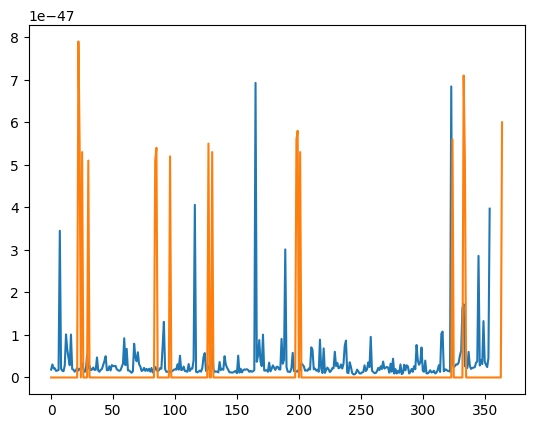

In [25]:


# 保存结果
combined_sd_y_South_central_Alaska = normal_sd_y.flatten()
plt.figure()
plt.plot(combined_sd_y_South_central_Alaska)
plt.plot([i/1e47 if i > 5 else 0 for i in earthquake_data[0]])

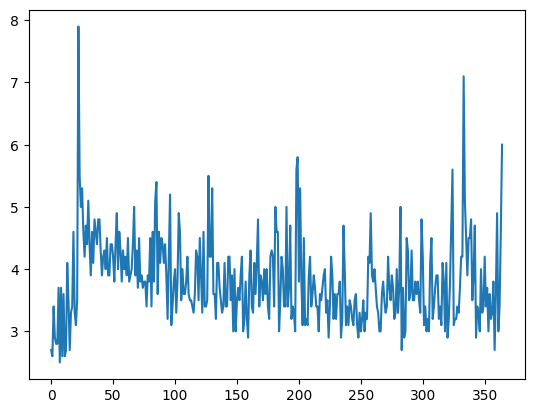

In [12]:
plt.plot(earthquake_data[0,:])